In [65]:
import xml.etree.ElementTree as ET

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy
import numpy as np
import pandas as pd

TC Marcia - 20 Feb 2015

In [4]:
infile = 'tracks/z_tigge_c_ecmf_20150218120000_ifs_glob_prod_all_glo.xml'

In [5]:
tree = ET.parse(infile)

In [6]:
root = tree.getroot()

In [7]:
root.tag

'cxml'

In [38]:
columns = [
    'model',
    'forecast type',
    'ensemble member',
    'TC id',
    'TC name',
    'TC number',
    'TC basin',
    'lead time (hours)',
    'UTC time',
    'latitude',
    'longitude',
    'minumum pressure (hPa)',
    'maximum wind speed (ms-1)',
    'maximum wind latitude',
    'maximum wind longitude',
]

ncols = len(columns)
data_array = []
for forecast in root:
    if forecast.tag == 'header':
        continue
    row = ['N/A'] * ncols
    print(forecast.tag, forecast.attrib)
    model = forecast.attrib['origin']
    row[0] = model
    forecast_type = forecast.attrib['type']
    row[1] = forecast_type
    if forecast_type == 'ensembleForecast':
        forecast_member = int(forecast.attrib['member'])
        row[2] = forecast_member
    for disturbance in forecast:
        print('  ', disturbance.tag, disturbance.attrib)
        tc_id = disturbance.attrib['ID']
        row[3] = tc_id
        if disturbance[0].tag == 'cycloneName':
            print('    ', disturbance[0].tag, disturbance[0].text)
            tc_name = disturbance[0].text
            row[4] = tc_name
            print('    ', disturbance[1].tag, disturbance[1].text)
            assert disturbance[1].tag == 'cycloneNumber'
            tc_number = disturbance[1].text
            row[5] = tc_number
            print('    ', disturbance[2].tag, disturbance[2].text)
            assert disturbance[2].tag == 'basin'
            tc_basin = disturbance[2].text
            row[6] = tc_basin
            fix_start = 3
        else:
            print('    ', disturbance[0].tag, disturbance[0].text)
            assert disturbance[0].tag == 'cycloneNumber'
            tc_number = int(disturbance[0].text)
            row[5] = tc_number
            print('    ', disturbance[1].tag, disturbance[1].text)
            assert disturbance[1].tag == 'basin'
            tc_basin = disturbance[1].text
            row[6] = tc_basin
            fix_start = 2
        if len(disturbance) > fix_start:
            for fix in disturbance[fix_start:]:
                print('    ', fix.tag, fix.attrib)
                try:
                    lead_time = int(fix.attrib['hour'])
                    row[7] = lead_time
                except KeyError:
                    pass
                print('      ', fix[0].tag, fix[0].text)
                assert fix[0].tag == 'validTime'
                utc_time = fix[0].text
                row[8] = utc_time
                print('      ', fix[1].tag, fix[1].text)
                assert fix[1].tag == 'latitude'
                latitude = float(fix[1].text)
                row[9] = latitude
                print('      ', fix[2].tag, fix[2].text)
                assert fix[2].tag == 'longitude'
                longitude = float(fix[2].text)
                row[10] = longitude
                if len(fix) > 3:
                    cdata = fix[3]
                    print('      ', cdata.tag)
                    print('        ', cdata[0].tag, cdata[0][0].text)
                    assert cdata[0].tag == 'minimumPressure'
                    min_pressure = float(cdata[0][0].text)
                    row[11] = min_pressure
                    print('        ', cdata[1].tag, cdata[1][0].text)
                    assert cdata[1].tag == 'maximumWind'
                    max_wind_speed = float(cdata[1][0].text)
                    row[12] = max_wind_speed
                    print('          ', cdata[1][1].tag, cdata[1][1].text)
                    assert cdata[1][1].tag == 'latitude'
                    max_wind_latitude = float(cdata[1][1].text)
                    row[13] = max_wind_latitude
                    print('          ', cdata[1][2].tag, cdata[1][2].text)
                    assert cdata[1][2].tag == 'longitude'
                    max_wind_longitude = float(cdata[1][2].text)
                    row[14] = max_wind_longitude
                print(row)
                data_array.append(row.copy())
        else:
            print(row)
            data_array.append(row.copy())

data {'origin': 'ecmf', 'type': 'analysis'}
   disturbance {'ID': '2015021812_110S_1365E'}
     cycloneName Lam
     cycloneNumber 13
     basin Southwest Pacific
     fix {'source': 'synoptic'}
       validTime 2015-02-18T12:00:00Z
       latitude 11
       longitude 136.5
['ecmf', 'analysis', 'N/A', '2015021812_110S_1365E', 'Lam', '13', 'Southwest Pacific', 'N/A', '2015-02-18T12:00:00Z', 11.0, 136.5, 'N/A', 'N/A', 'N/A', 'N/A']
   disturbance {'ID': '2015021812_181S_1546E'}
     cycloneName Marcia
     cycloneNumber 14
     basin Southwest Pacific
     fix {'source': 'synoptic'}
       validTime 2015-02-18T12:00:00Z
       latitude 18.1
       longitude 154.6
['ecmf', 'analysis', 'N/A', '2015021812_181S_1546E', 'Marcia', '14', 'Southwest Pacific', 'N/A', '2015-02-18T12:00:00Z', 18.1, 154.6, 'N/A', 'N/A', 'N/A', 'N/A']
data {'origin': 'ecmf', 'type': 'forecast'}
   disturbance {'ID': '2015021812_110S_1365E'}
     cycloneName Lam
     cycloneNumber 13
     basin Southwest Pacific
     

In [39]:
df = pd.DataFrame(data_array, columns=columns)

In [40]:
df

,model,forecast type,ensemble member,TC id,TC name,TC number,TC basin,lead time (hours),UTC time,latitude,longitude,minumum pressure (hPa),maximum wind speed (ms-1),maximum wind latitude,maximum wind longitude
0,ecmf,analysis,N/A,2015021812_110S_1365E,Lam,13,Southwest Pacific,N/A,2015-02-18T12:00:00Z,11.0,136.5,N/A,N/A,N/A,N/A
1,ecmf,analysis,N/A,2015021812_181S_1546E,Marcia,14,Southwest Pacific,N/A,2015-02-18T12:00:00Z,18.1,154.6,N/A,N/A,N/A,N/A
2,ecmf,forecast,N/A,2015021812_110S_1365E,Lam,13,Southwest Pacific,0,2015-02-18T12:00:00Z,10.8,136.5,981.0,29.3,10.6,136.4
3,ecmf,forecast,N/A,2015021812_110S_1365E,Lam,13,Southwest Pacific,6,2015-02-18T18:00:00Z,10.8,136.6,972.0,34.0,10.7,136.8
4,ecmf,forecast,N/A,2015021812_110S_1365E,Lam,13,Southwest Pacific,12,2015-02-19T00:00:00Z,11.4,136.4,970.0,36.0,11.3,136.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2516,ecmf,ensembleForecast,50,2015021812_181S_1546E,Marcia,14,Southwest Pacific,36,2015-02-20T00:00:00Z,22.8,150.6,1001.0,16.5,22.0,152.7
2517,ecmf,ensembleForecast,50,2015021812_181S_1546E,Marcia,14,Southwest Pacific,42,2015-02-20T06:00:00Z,23.4,151.0,1000.0,14.4,23.1,152.4
2518,ecmf,ensembleForecast,50,2015021812_181S_1546E,Marcia,14,Southwest Pacific,48,2015-02-20T12:00:00Z,24.0,151.5,1004.0,11.8,24.3,153.0
2519,ecmf,ensembleForecast,50,2015021812_181S_1546E,Marcia,14,Southwest Pacific,54,2015-02-20T18:00:00Z,24.8,152.1,1004.0,13.4,24.3,153.2


In [41]:
df['TC name'].unique()

<StringArray>
['Lam', 'Marcia']
Length: 2, dtype: str

In [43]:
forecast = df[(df['TC name'] == 'Marcia') & (df['ensemble member'] == 0)]

In [44]:
forecast

,model,forecast type,ensemble member,TC id,TC name,TC number,TC basin,lead time (hours),UTC time,latitude,longitude,minumum pressure (hPa),maximum wind speed (ms-1),maximum wind latitude,maximum wind longitude
92,ecmf,ensembleForecast,0,2015021812_181S_1546E,Marcia,14,Southwest Pacific,0,2015-02-18T12:00:00Z,18.1,154.4,998.0,17.5,19.2,154.9
93,ecmf,ensembleForecast,0,2015021812_181S_1546E,Marcia,14,Southwest Pacific,6,2015-02-18T18:00:00Z,19.2,153.2,995.0,17.5,19.5,154.4
94,ecmf,ensembleForecast,0,2015021812_181S_1546E,Marcia,14,Southwest Pacific,12,2015-02-19T00:00:00Z,19.8,152.1,998.0,16.5,20.3,151.8
95,ecmf,ensembleForecast,0,2015021812_181S_1546E,Marcia,14,Southwest Pacific,18,2015-02-19T06:00:00Z,20.3,151.5,995.0,15.4,21.2,151.0
96,ecmf,ensembleForecast,0,2015021812_181S_1546E,Marcia,14,Southwest Pacific,24,2015-02-19T12:00:00Z,20.9,151.3,998.0,16.5,22.6,151.0
97,ecmf,ensembleForecast,0,2015021812_181S_1546E,Marcia,14,Southwest Pacific,30,2015-02-19T18:00:00Z,21.7,150.8,996.0,15.9,22.6,152.1
98,ecmf,ensembleForecast,0,2015021812_181S_1546E,Marcia,14,Southwest Pacific,36,2015-02-20T00:00:00Z,22.6,150.7,1000.0,15.4,23.1,151.8
99,ecmf,ensembleForecast,0,2015021812_181S_1546E,Marcia,14,Southwest Pacific,42,2015-02-20T06:00:00Z,23.4,150.7,999.0,13.4,23.4,151.8
100,ecmf,ensembleForecast,0,2015021812_181S_1546E,Marcia,14,Southwest Pacific,48,2015-02-20T12:00:00Z,23.4,151.0,1004.0,14.4,27.4,153.5
101,ecmf,ensembleForecast,0,2015021812_181S_1546E,Marcia,14,Southwest Pacific,54,2015-02-20T18:00:00Z,23.7,151.0,1004.0,11.8,27.1,153.2


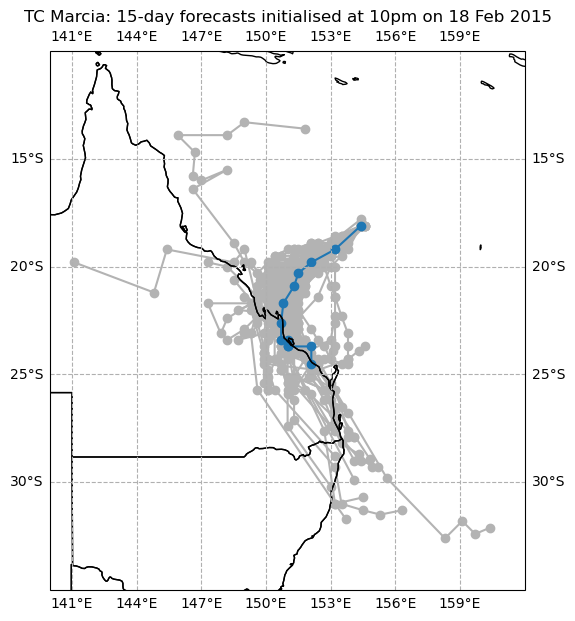

In [78]:
fig = plt.figure(figsize=[7, 7])
ax1 = fig.add_subplot(111, projection=ccrs.PlateCarree())

for member in np.arange(1, 51):
    forecast = df[(df['TC name'] == 'Marcia') & (df['ensemble member'] == member)]
    ax1.plot(
        forecast['longitude'].values,
        forecast['latitude'].values * -1,
        marker='o',
        color='0.7',
        zorder=0.5,
        transform=ccrs.PlateCarree(),
        label='perturbed forecasts'
    )

forecast = df[(df['TC name'] == 'Marcia') & (df['ensemble member'] == 0)]
ax1.plot(
    forecast['longitude'].values,
    forecast['latitude'].values * -1,
    marker='o',
    color='tab:blue',
    zorder=0.5,
    transform=ccrs.PlateCarree(),
    label='control forecast',
)

ax1.coastlines()
ax1.add_feature(cartopy.feature.STATES)
ax1.set_extent([140, 162, -10, -35], crs=ccrs.PlateCarree())
ax1.gridlines(linestyle='--', draw_labels=True)
ax1.set_title('TC Marcia: 15-day forecasts initialised at 10pm on 18 Feb 2015')
#ax1.legend()

plt.show()